# Notebook 1: Exploratory Data Analysis (EDA)
**Project:** Sentiment Analysis on Trustpilot Marketing Reviews  
**Client:** Candy Factory Group – Pannipitiya  
**Dataset:** Trustpilot Reviews (June 2022) - 3,698 reviews | 214 companies

## 1. Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
import warnings
warnings.filterwarnings('ignore')

# Create output folders if they don't exist
os.makedirs('../reports/figures', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load Dataset

In [29]:
df = pd.read_csv('../data/raw/trust_pilot_reviews_data_2022_06.csv')

# Parse reviewed_at as datetime
df['reviewed_at'] = pd.to_datetime(df['reviewed_at'], errors='coerce')

print(f"Shape     : {df.shape}")
print(f"Columns   : {df.columns.tolist()}")
print(f"Date range: {df['reviewed_at'].min().date()} -> {df['reviewed_at'].max().date()}")
df.head(5)

Shape     : (3698, 11)
Columns   : ['name', 'company_url', 'trustpilot_url', 'description', 'author_name', 'review_title', 'review_text', 'rating', 'reviewed_at', 'uniq_id', 'scraped_at']
Date range: 2014-05-19 -> 2022-06-18


,name,company_url,trustpilot_url,description,author_name,review_title,review_text,rating,reviewed_at,uniq_id,scraped_at
0,Poundshop,https://www.poundshop.com/,https://uk.trustpilot.com/review/www.poundshop...,"The home for top brands, amazing value! We hav...",Colin,Lowest price in the country,Lowest price in the country for what we wanted...,5,2022-06-18 12:08:09+00:00,7e0edfe9-7251-5561-acc8-34f7d3ab79aa,06/18/22
1,Poundshop,https://www.poundshop.com/,https://uk.trustpilot.com/review/www.poundshop...,"The home for top brands, amazing value! We hav...",Mr Paul Harrison,got it on time they took notice that I…,got it on time they took notice that I let the...,5,2022-06-18 11:48:20+00:00,7e0edfe9-7251-5561-acc8-34f7d3ab79aa,06/18/22
2,Poundshop,https://www.poundshop.com/,https://uk.trustpilot.com/review/www.poundshop...,"The home for top brands, amazing value! We hav...",Mrs Dean,Delivered on time,"Delivered on time. Products as described, pack...",5,2022-06-18 11:32:52+00:00,7e0edfe9-7251-5561-acc8-34f7d3ab79aa,06/18/22
3,Poundshop,https://www.poundshop.com/,https://uk.trustpilot.com/review/www.poundshop...,"The home for top brands, amazing value! We hav...",Mrs Barlow,Quick and efficient service..,Quick and efficient service..Pleased,5,2022-06-18 11:29:27+00:00,7e0edfe9-7251-5561-acc8-34f7d3ab79aa,06/18/22
4,Poundshop,https://www.poundshop.com/,https://uk.trustpilot.com/review/www.poundshop...,"The home for top brands, amazing value! We hav...",Graham Bradbury,Excellent service packed well,Excellent service packed well. Really pleased.,5,2022-06-18 11:22:37+00:00,7e0edfe9-7251-5561-acc8-34f7d3ab79aa,06/18/22


## 3. Basic Dataset Info

In [30]:
# Data types and null counts
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Data Types ===
name                              str
company_url                       str
trustpilot_url                    str
description                       str
author_name                       str
review_title                      str
review_text                       str
rating                          int64
reviewed_at       datetime64[us, UTC]
uniq_id                           str
scraped_at                        str
dtype: object

=== Missing Values ===
name                0
company_url         0
trustpilot_url      0
description       686
author_name         1
review_title        0
review_text         0
rating              0
reviewed_at         0
uniq_id             0
scraped_at          0
dtype: int64


In [31]:
# Basic statistics
print(f"Total reviews     : {len(df)}")
print(f"Unique companies  : {df['name'].nunique()}")
print(f"Date range        : {df['reviewed_at'].min()} -> {df['reviewed_at'].max()}")
print(f"Rating range      : {df['rating'].min()} – {df['rating'].max()}")

Total reviews     : 3698
Unique companies  : 214
Date range        : 2014-05-19 12:18:11+00:00 -> 2022-06-18 12:25:34+00:00
Rating range      : 1 – 5


## 4. Rating Distribution
Rating scale: 1 (worst) -> 5 (best). This will be used to assign sentiment labels later.

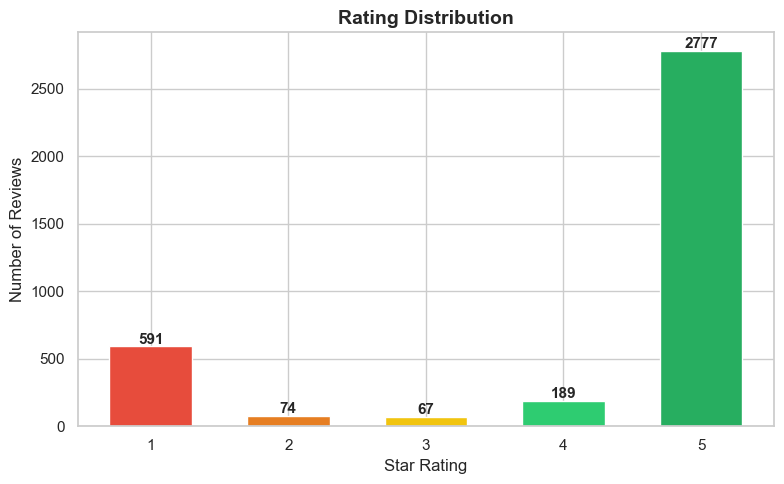

rating
1     591
2      74
3      67
4     189
5    2777
Name: count, dtype: int64


In [32]:
# Rating distribution bar chart
rating_counts = df['rating'].value_counts().sort_index()

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
plt.figure(figsize=(8, 5))
bars = plt.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontsize=11, fontweight='bold')

plt.title('Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.xticks([1, 2, 3, 4, 5], ['1', '2', '3', '4', '5'])
plt.tight_layout()
plt.savefig('../reports/figures/rating_distribution.png', dpi=150)
plt.show()

print(rating_counts)

## 5. Assign Sentiment Labels
Map star ratings -> Positive / Neutral / Negative

In [33]:
# Sentiment label mapping
def assign_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['rating'].apply(assign_sentiment)

print("Sentiment distribution:")
print(df['sentiment'].value_counts())

Sentiment distribution:
sentiment
Positive    2966
Negative     665
Neutral       67
Name: count, dtype: int64


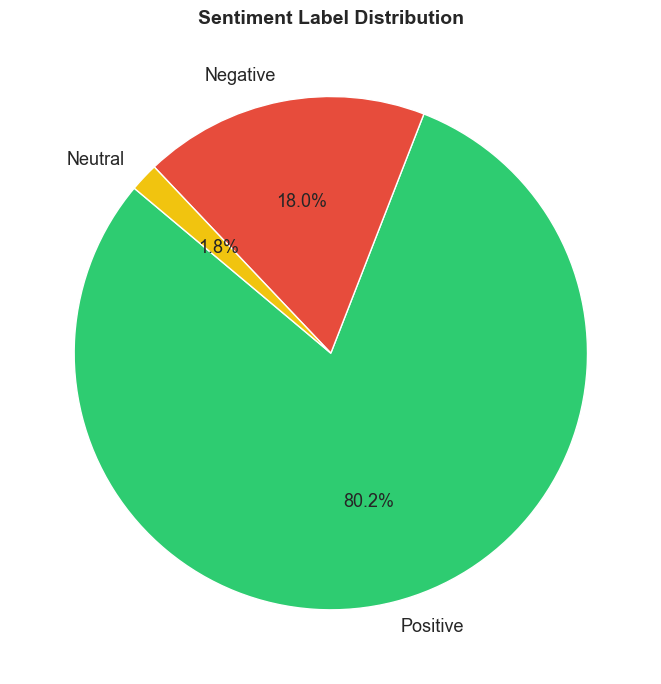

In [34]:
sentiment_counts = df['sentiment'].value_counts()

# Map colors to labels explicitly - not by position
color_map = {'Positive': '#2ecc71', 'Neutral': '#f1c40f', 'Negative': '#e74c3c'}
colors_pie = [color_map[label] for label in sentiment_counts.index]

plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 13}
)
plt.title('Sentiment Label Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/sentiment_distribution.png', dpi=150)
plt.show()

## 6. Review Length Analysis
Longer reviews often carry more detail — useful to understand before modeling.

In [35]:
# Add review length column (word count)
df['review_length'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))

print("Review length stats:")
print(df['review_length'].describe())

Review length stats:
count    3698.000000
mean       45.332883
std        55.957762
min         1.000000
25%        12.000000
50%        28.000000
75%        56.000000
max       892.000000
Name: review_length, dtype: float64


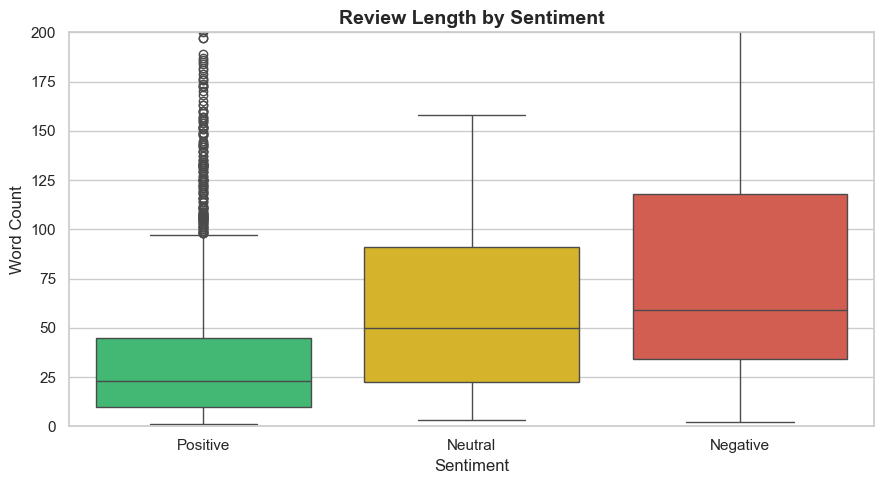

In [36]:
# Review length by sentiment (boxplot)
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='sentiment',
    y='review_length',
    palette={'Positive': '#2ecc71', 'Neutral': '#f1c40f', 'Negative': '#e74c3c'},
    order=['Positive', 'Neutral', 'Negative']
)
plt.title('Review Length by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.ylim(0, 200)
plt.tight_layout()
plt.savefig('../reports/figures/review_length_by_sentiment.png', dpi=150)
plt.show()

## 7. Top 10 Companies by Review Count

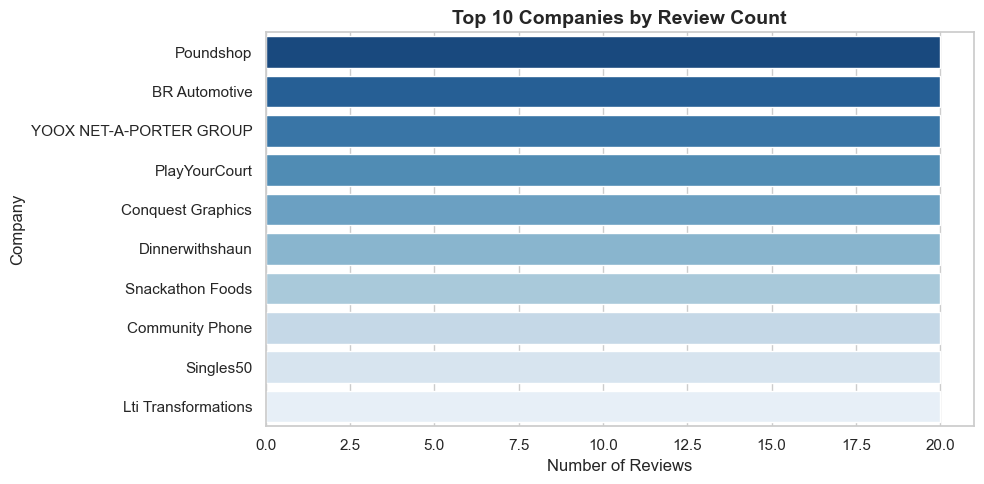

In [37]:
# Top 10 companies
top_companies = df['name'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_companies.values, y=top_companies.index, palette='Blues_r')
plt.title('Top 10 Companies by Review Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Reviews')
plt.ylabel('Company')
plt.tight_layout()
plt.savefig('../reports/figures/top_companies.png', dpi=150)
plt.show()

## 8. Word Clouds — Positive vs Negative Reviews
Visual snapshot of the most frequent words in each sentiment class.

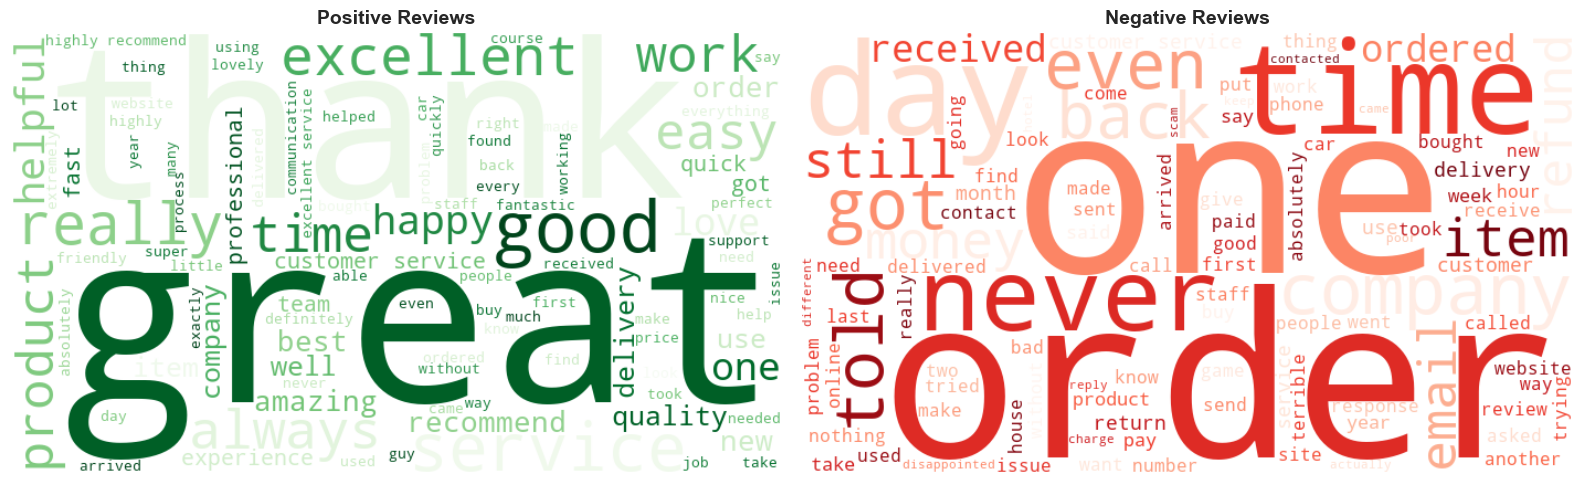

In [38]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

## Remove stopwords before generating
stop_words = set(stopwords.words('english'))

## Word cloud
def filter_text_for_wordcloud(text_series):
    combined = ' '.join(text_series.astype(str).tolist()).lower()
    tokens = combined.split()
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 2]
    return ' '.join(filtered)

positive_text = filter_text_for_wordcloud(df[df['sentiment'] == 'Positive']['review_text'])
negative_text = filter_text_for_wordcloud(df[df['sentiment'] == 'Negative']['review_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=700, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews', fontsize=14, fontweight='bold')
axes[0].axis('off')

wc_neg = WordCloud(width=700, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../reports/figures/wordclouds.png', dpi=150)
plt.show()

## 9. Save Labelled Dataset for Next Notebook

In [39]:
# Save labelled dataset to processed folder
df.to_csv('../data/processed/reviews_labelled.csv', index=False)
print(f"Saved reviews_labelled.csv — {len(df)} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Saved reviews_labelled.csv — 3698 rows, 13 columns
Columns: ['name', 'company_url', 'trustpilot_url', 'description', 'author_name', 'review_title', 'review_text', 'rating', 'reviewed_at', 'uniq_id', 'scraped_at', 'sentiment', 'review_length']


## EDA Summary

| Finding | Detail |
|---|---|
| Total reviews | 3,698 |
| Unique companies | 214 |
| Dominant rating | 5-star - 75% of reviews |
| Class imbalance | Positive >> Negative - needs balancing in modeling |
| Avg review length | ~20–30 words |
| Saved output | `data/processed/reviews_labelled.csv` |

**Next -> `02_preprocessing.ipynb` for text cleaning pipeline**